### 1. 환경설정

In [ ]:
!pip install anthropic python-docx -q

import os, json, time, statistics, copy, shutil, re
import anthropic
from pathlib import Path
from google.colab import userdata, drive
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

os.environ['ANTHROPIC_API_KEY'] = userdata.get('kdcottot')
client = anthropic.Anthropic()

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

print('환경설정 완료')

환경설정 완료


### 2. 폰트 설정

In [ ]:
import matplotlib.font_manager as fm

cache_dir = os.path.join(os.path.expanduser('~'), '.cache', 'matplotlib')
if os.path.exists(cache_dir):
    for fname in os.listdir(cache_dir):
        if fname.startswith('fontlist-'):
            os.remove(os.path.join(cache_dir, fname))
fm._load_fontmanager(try_read_cache=False)
print('폰트 캐시 재구축 완료')

폰트 캐시 재구축 완료


### 3. Google Drive 마운트

In [ ]:
drive.mount('/content/drive')

DRIVE_DIR = Path('/content/drive/MyDrive/설계학회 논문 실험 0523/수정3 - 에이전트 변경, 프롬프트 변경, 인풋추가')
DRIVE_DIR.mkdir(exist_ok=True)

# 참고자료 폴더
REF_DIR = Path('/content/drive/MyDrive/성수분석자료')

print(f'참고자료 경로: {REF_DIR}')
print('결과 저장 경로: ' + str(DRIVE_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
참고자료 경로: /content/drive/MyDrive/성수분석자료
결과 저장 경로: /content/drive/MyDrive/설계학회 논문 실험 0523/수정3 - 에이전트 변경, 프롬프트 변경, 인풋추가


In [ ]:
!pip install pymupdf -q

In [ ]:
import base64
import fitz  # pymupdf

def summarize_for_urban_reasoning(content, is_image=False, filename=''):
    prompt_text = (
        f'이 자료({filename})를 도시문제 해석과 도시설계 전략 도출에 활용할 수 있도록 요약하라. '
        f'다음 항목을 포함하라: '
        f'1) 핵심 현상, '
        f'2) 문제의 원인 또는 발생 메커니즘, '
        f'3) 공간·보행·교통·개발·운영 측면의 시사점, '
        f'4) 실현 가능성과 관련된 제약·주체·조건, '
        f'5) 중요한 수치와 고유명사. '
        f'사실을 왜곡하지 말고, 자료에 없는 내용은 추가하지 말며, 800자 이내로 구조적으로 정리하라.'
    )

    if is_image:
        if isinstance(content, list):
            msg_content = []
            for img_b64 in content:
                msg_content.append({
                    'type': 'image',
                    'source': {'type': 'base64', 'media_type': 'image/png', 'data': img_b64}
                })
            msg_content.append({'type': 'text', 'text': prompt_text})
        else:
            ext = Path(filename).suffix.lower()
            media_type = 'image/png' if ext == '.png' else 'image/jpeg'
            msg_content = [
                {'type': 'image', 'source': {'type': 'base64', 'media_type': media_type, 'data': content}},
                {'type': 'text', 'text': prompt_text}
            ]
    else:
        msg_content = f'{prompt_text}\n\n{content[:12000]}'

    response = client.messages.create(
        model='claude-sonnet-4-6',
        max_tokens=900,
        messages=[{'role': 'user', 'content': msg_content}]
    )
    return response.content[0].text

def load_pdf_as_text(file_path):
    """PDF에서 텍스트 추출"""
    doc = fitz.open(str(file_path))
    text = ''
    for page in doc:
        text += page.get_text()
    doc.close()
    return text

# REF_DIR에서 파일 로딩 후 summaries 생성
summaries = {}
for file_path in sorted(REF_DIR.iterdir()):
    ext = file_path.suffix.lower()

    if ext in ['.txt', '.md', '.csv']:
        content = file_path.read_text(encoding='utf-8')
        is_image = False
    elif ext in ['.png', '.jpg', '.jpeg']:
        content = base64.b64encode(file_path.read_bytes()).decode('utf-8')
        is_image = True
    elif ext == '.pdf':
        print(f'PDF 텍스트 추출 중: {file_path.name}')
        content = load_pdf_as_text(file_path)
        is_image = False
    else:
        print(f'스킵: {file_path.name}')
        continue

    print(f'요약 중: {file_path.name}')
    summaries[file_path.name] = summarize_for_urban_reasoning(content, is_image=is_image, filename=file_path.name)

print(f'\n요약 완료: {len(summaries)}개')

PDF 텍스트 추출 중: (서울시 빅데이터 담당관) 통신3사 통신위치정보(CPS) 확보 등 기술자문.pdf
요약 중: (서울시 빅데이터 담당관) 통신3사 통신위치정보(CPS) 확보 등 기술자문.pdf
PDF 텍스트 추출 중: Almeida_Human Stampedes a review.pdf
요약 중: Almeida_Human Stampedes a review.pdf
PDF 텍스트 추출 중: Gayathri_A review of studies on understanding crowd dynamics.pdf
요약 중: Gayathri_A review of studies on understanding crowd dynamics.pdf
PDF 텍스트 추출 중: Helbing_Pedestrian, Crowd, and Evacuation Dynamics.pdf
요약 중: Helbing_Pedestrian, Crowd, and Evacuation Dynamics.pdf
PDF 텍스트 추출 중: Helbing_Simulation of pedestrian crowds in normal and evacuation.pdf
요약 중: Helbing_Simulation of pedestrian crowds in normal and evacuation.pdf
PDF 텍스트 추출 중: KBS NEWS.pdf
요약 중: KBS NEWS.pdf
PDF 텍스트 추출 중: Kant_Accimap and crowd flow in urban infrastructure.pdf
요약 중: Kant_Accimap and crowd flow in urban infrastructure.pdf
PDF 텍스트 추출 중: Kefan_Analysis of crowd stampede risk mechanism.pdf
요약 중: Kefan_Analysis of crowd st

In [ ]:
# 참고자료 텍스트 생성
reference_text = '\n\n'.join([f'[{name}]\n{summary}' for name, summary in summaries.items()])
print(f'\n참고자료 준비 완료 ({len(summaries)}개)')


참고자료 준비 완료 (23개)


### 4. 실험환경 설정
논문 기재용 실험 변수를 명시적으로 선언한다.

In [ ]:
EXP_CONFIG = {
    'model':       'claude-sonnet-4-6',
    'api':         'Anthropic Messages API',
    'temperature': 1.0,    # 생성 다양성 제어 (0.0 고정 ~ 1.0 최대)
    'max_tokens':  8096,   # 최대 출력 토큰 수
    'num_runs':    10,     # 조건별 반복 실험 횟수
    'date':        time.strftime('%Y-%m-%d'),
}

MODEL_NAME  = EXP_CONFIG['model']
TEMPERATURE = EXP_CONFIG['temperature']
MAX_TOKENS  = EXP_CONFIG['max_tokens']
MAX_RUNS    = EXP_CONFIG['num_runs']

print('실험환경 설정 완료')
print(json.dumps(EXP_CONFIG, ensure_ascii=False, indent=2))

실험환경 설정 완료
{
  "model": "claude-sonnet-4-6",
  "api": "Anthropic Messages API",
  "temperature": 1.0,
  "max_tokens": 8096,
  "num_runs": 10,
  "date": "2026-05-23"
}


In [ ]:
if 'reference_text' not in globals():
    reference_text = ""

reference_block = ""
if isinstance(reference_text, str) and reference_text.strip():
    reference_block = f"\n- 참고자료\n{reference_text.strip()}"



import textwrap

SYSTEM_PROMPT = (
    '당신은 공간을 중심으로 도시 교통·보행 안전 및 군중관리 전문가다.\n'
    '도시문제를 분석하고 공간적 해결 전략을 제안하라.'
)


COMMON_PROMPT = (
    '[분석대상]\n'
    '성수동 방문인구 증가로 성수역 출입구(특히 2번, 3번) 주변\n'
    '군중 밀도가 지나치게 높아 안전사고 위험이 발생하고 있는 현상\n'
    '\n'
    '[맥락정보]\n'
    '- 2024년 12월 기준 일평균 유동인구 서울 1위\n'
    '- 퇴근시간대(18~19시) 이용객 24만명 (9년 전 대비 +9만명)\n'
    '- 성수카페거리 권역 실시간 생활인구 약 26,000~28,000명\n'
    '- 집계 구역당 실시간 밀도 약 380~390명\n'
    '- 출입구 4개, 3번 출구 퇴근시간 이용률 31.1%\n'
    '- 3번 출구 인근: 지식산업센터·팝업스토어·카페거리 밀집\n'
    '- 승강장 폭 협소, 전 출구 에스컬레이터 단일 구조\n'
    '- 인근 버스 노선 4개, 뚝섬역까지 도보 연결 가능\n'
    '- 방문층: 2030세대 여성 관광·트렌드 수요 + 무신사·크래프톤·SM 직장인\n'
    '- 예정 개발: 삼표산업 부지·크래프톤 신사옥·성수전략정비구역 재개발\n'
    '- 진행중: 3-1번 출입구 신설 공사 (2025년 12월 준공 목표)\n'
    '{reference_block}'
    '\n'
    '[출력형식]\n'
    '위 분석대상의 문제점을 진단하고, 창의적인 해결 전략을 제시하라.'
)


COT_FEWSHOT = [
    {'role': 'user',      'content': '식당에 사과가 23개 있었습니다. 점심준비에 20개를 사용하고 6개를 더 샀다면, 사과가 몇 개 남았나요?'},
    {'role': 'assistant', 'content': '먼저 현재 상태를 확인한다.\n사과는 23개다.\n다음으로 점심준비에 20개를 사용했으므로, 23-20 = 3개가 남는다.\n마지막으로 6개를 추가로 구매하였으므로, 3 + 6 = 9개가 된다.\n따라서 사과는 9개가 남는다.'},
    {'role': 'user',      'content': '지민이는 사람들이 있는 곳으로 가고 싶어 했습니다. 어디로 갔을까요?\n선택지: (a) 도서관 (b) 백화점 (c) 산 정상 (d) 집'},
    {'role': 'assistant', 'content': '먼저 질문의 조건을 확인한다. 지민이는 사람들이 많은 곳을 원한다.\n다음으로 각 선택지의 성격을 순서대로 확인한다.\n(a)는 조용한 곳으로 사람이 적다.\n(c)는 접근이 어려워 사람이 드물다.\n(d)는 개인 공간이다.\n(b)는 상업시설로 상시 다수의 방문객이 모이는 곳이다.\n조건과 가장 일치하는 선택지는 백화점이므로 정답은 (b)다.'},
    {'role': 'user',      'content': '"Bangtan Boys"라는 단어의 마지막 글자들을 취해 연결하세요.'},
    {'role': 'assistant', 'content': '먼저 문장을 단어 단위로 분리한다.\n"Bangtan"과 "Boys" 두 단어로 나뉜다.\n다음으로 각 단어의 마지막 글자를 순서대로 추출한다.\n"Bangtan"의 마지막 글자는 "n"이고, "Boys"의 마지막 글자는 "s"다.\n마지막으로 추출한 글자를 순서대로 연결하면 "ns"가 된다.\n따라서 정답은 "ns"다.'},
    {'role': 'user',      'content': '다음의 문제풀이 방식을 학습하고 내가 다른 문제를 내면 같은 구조로 문제를 해결해줘.\n예시의 내용 자체를 반복하지 말고, 예시의 구조와 전개 방식만 적용해줘.\n이 구조는 하나의 사고 경로를 따라 단계별로 순차 추론하며, 각 단계의 결론이 다음 단계의 근거가 되는 선형적 구조임을 기억하라.'},
]

TOT_FEWSHOT = [
    {'role': 'user',      'content': '식당에 사과가 23개 있었습니다. 점심준비에 20개를 사용하고 6개를 더 샀다면, 사과가 몇 개 남았나요?'},
    {'role': 'assistant', 'content': '이 문제를 풀기 위한 경로는 세 가지다.\n(A) 사용 먼저 계산 후 구매 반영,\n(B) 구매 먼저 반영 후 사용 차감,\n(C) 전체 증감을 한번에 계산.\n\n(A) 검토: 23 - 20 = 3, 3 + 6 = 9. 단계가 명확하고 오류 가능성이 낮다. 유효.\n(B) 검토: 23 + 6 = 29, 29 - 20 = 9. 결과는 같으나 시간 순서와 맞지 않아 직관성이 떨어진다. 보류.\n(C) 검토: 23 + (6 - 20) = 9. 중간 값이 음수가 되어 현실적 해석이 어렵다. 제거.\n\n(A) 경로가 가장 직관적이고 오류 가능성이 낮으므로 채택한다. 따라서 사과는 9개가 남는다.'},
    {'role': 'user',      'content': '지민이는 사람들이 있는 곳으로 가고 싶어 했습니다. 어디로 갔을까요?\n선택지: (a) 도서관 (b) 백화점 (c) 산 정상 (d) 집'},
    {'role': 'assistant', 'content': '판단 기준을 두 가지로 설정한다.\n(기준 1) 상시 다수 인원이 존재하는가,\n(기준 2) 목적 없이 접근 가능한 공간인가.\n\n(a): 기준 1 미충족, 기준 2 부분 충족. 제거.\n(b): 기준 1 충족, 기준 2 충족. 유효. 확장.\n(c): 기준 1 미충족, 기준 2 미충족. 제거.\n(d): 기준 1 미충족, 기준 2 미충족. 제거.\n\n유효 경로는 (b)만 남는다. 백화점은 두 기준을 모두 충족하므로 정답은 (b)다.'},
    {'role': 'user',      'content': '"Bangtan Boys"라는 단어의 마지막 글자들을 취해 연결하세요.'},
    {'role': 'assistant', 'content': '문제 해석 방식으로 세 가지 경로를 설정한다.\n(A) 전체 문자열의 마지막 글자만 추출,\n(B) 각 단어의 마지막 글자 추출 후 연결,\n(C) 각 단어의 첫 글자와 마지막 글자를 혼합 추출.\n\n(A) 검토: 마지막 글자는 "s". 복수형을 요구하므로 의도와 불일치. 제거.\n(B) 검토: "Bangtan" -> "n", "Boys" -> "s". 지시에 정확히 부합. 채택.\n(C) 검토: 첫 글자 혼합은 근거 없음. 제거.\n\n(B) 경로를 확장하면 "ns"가 도출된다. 따라서 정답은 "ns"다.'},
    {'role': 'user',      'content': '다음의 문제풀이 방식을 학습하고 내가 다른 문제를 내면 같은 구조로 문제를 해결해줘.\n예시의 내용 자체를 반복하지 말고, 예시의 구조와 전개 방식만 적용해줘.\n이 구조는 복수의 해석 경로를 병렬로 설정하고, 각 경로를 평가·가지치기한 뒤 유효한 경로만 확장하는 분기형 탐색 구조임을 기억하라.'},
]

CONDITIONS = [
    {'key': 'zero_shot', 'label': 'Zero-shot (무학습)', 'fewshot': []},
    {'key': 'cot',       'label': 'Few-shot CoT',       'fewshot': COT_FEWSHOT},
    {'key': 'tot',       'label': 'Few-shot ToT',       'fewshot': TOT_FEWSHOT},
]

print('프롬프트 정의 완료')
print(f'  system: {SYSTEM_PROMPT}')
for c in CONDITIONS:
    print(f"  - {c['label']} | few-shot: {len(c['fewshot'])}개 메시지")

프롬프트 정의 완료
  system: 당신은 공간을 중심으로 도시 교통·보행 안전 및 군중관리 전문가다.
도시문제를 분석하고 공간적 해결 전략을 제안하라.
  - Zero-shot (무학습) | few-shot: 0개 메시지
  - Few-shot CoT | few-shot: 7개 메시지
  - Few-shot ToT | few-shot: 7개 메시지


### 6. 유틸 함수 (저장/로드/Word)

In [ ]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

def save_json(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def safe_copy(src):
    shutil.copy(src, DRIVE_DIR / Path(src).name)

def save_docx(results, condition):
    """실험 결과를 Word 파일로 저장"""
    doc = Document()
    doc.add_heading(condition['label'], 0).alignment = WD_ALIGN_PARAGRAPH.CENTER

    # 실험환경
    doc.add_heading('실험환경', level=1)
    for k, v in EXP_CONFIG.items():
        doc.add_paragraph(f'{k}: {v}')

    # 수행지시 프롬프트
    doc.add_heading('수행지시 프롬프트 (system: Role + Instruction)', level=1)
    doc.add_paragraph(SYSTEM_PROMPT)

    # 추론구조 학습
    doc.add_heading('추론구조 학습 프롬프트 (messages 앞부분)', level=1)
    if condition['fewshot']:
        doc.add_paragraph(f"Few-shot 메시지 수: {len(condition['fewshot'])}개")
    else:
        doc.add_paragraph('없음 (Zero-shot)')

    # 공통 프롬프트
    doc.add_heading('공통 프롬프트 (messages 마지막: Input Data + Context + Output Indicator)', level=1)
    doc.add_paragraph(COMMON_PROMPT)

    # 응답 결과
    doc.add_heading('실험 결과', level=1)
    for r in results:
        doc.add_heading(f"실험 {r['run_id']}회차", level=2)
        doc.add_paragraph(
            f"토큰: {r['total_tokens']:,} | 소요시간: {r['elapsed_sec']}초 | "
            f"Input: {r['input_tokens']} | Output: {r['output_tokens']}"
        )
        doc.add_heading('실험 결과', level=3)
        doc.add_paragraph(r['text'])
        doc.add_paragraph('─' * 50)

    key = condition['key']
    out = RESULTS_DIR / f'{key}_results.docx'
    doc.save(out)
    safe_copy(out)
    print(f"✅ {condition['label']} Word 저장 완료 ({len(results)}회)")

print('유틸 함수 정의 완료')

유틸 함수 정의 완료


### 7. Zero-shot 실험

In [ ]:
MAX_RUNS = 10

cond    = CONDITIONS[0]  # Zero-shot
zs_path = DRIVE_DIR / 'zero_shot_results.json'
zero_shot_results = load_json(zs_path) if zs_path.exists() else []

while len(zero_shot_results) < MAX_RUNS:
    run_id   = len(zero_shot_results) + 1
    messages = list(cond['fewshot']) + [{'role': 'user', 'content': COMMON_PROMPT}]

    print(f'=== {cond["label"]} — {run_id}회차 시작 ===')
    t0 = time.time()
    response = client.messages.create(
        model       = MODEL_NAME,
        max_tokens  = MAX_TOKENS,
        temperature = TEMPERATURE,
        system      = SYSTEM_PROMPT,
        messages    = messages
    )
    elapsed = round(time.time() - t0, 2)

    result = {
        'run_id':        run_id,
        'condition_key': cond['key'],
        'exp_env':       EXP_CONFIG,
        'text':          response.content[0].text,
        'input_tokens':  response.usage.input_tokens,
        'output_tokens': response.usage.output_tokens,
        'total_tokens':  response.usage.input_tokens + response.usage.output_tokens,
        'elapsed_sec':   elapsed
    }
    zero_shot_results.append(result)
    save_json(zero_shot_results, zs_path)

    print(f'[실험 결과]\n{result["text"]}')
    print('완료: {}회차 | 토큰: {:,} | 소요: {}초 | 누적: {}/{}'.format(
        run_id, result['total_tokens'], elapsed, len(zero_shot_results), MAX_RUNS))

save_docx(zero_shot_results, cond)
print(f'Zero-shot {MAX_RUNS}회 완료')

=== Zero-shot (무학습) — 4회차 시작 ===
[실험 결과]
# 성수역 군중 밀도 과부하 문제 진단 및 공간 해결 전략

---

## 1. 문제 진단: 무엇이 왜 위험한가

### 1-1. 공간 구조적 병목 (Physical Bottleneck)

```
[지하 승강장] → [단일 에스컬레이터] → [협소 출입구 통로] → [지상 집결점]
      ↑                  ↑                       ↑
  폭 협소          단방향 단선           출구별 용량 불균형
```

**3번 출구의 구조적 과부하:**
- 전체 이용객의 31.1% 집중 → 4개 출구 균등 분산 시 25% 기준 대비 **약 6% 초과 집중**
- 지식산업센터(통근) + 카페거리(관광) + 팝업스토어(이벤트 수요)가 **단일 출구 반경에 중첩**
- 에스컬레이터 단일 구조 → 역방향 전환 불가 → 혼잡 시 **병목 지점 해소 수단 부재**

### 1-2. 시간·수요 패턴의 이중 충돌

| 시간대 | 수요 유형 | 이동 방향 | 충돌 양상 |
|--------|-----------|-----------|-----------|
| 18~19시 | 직장인 퇴근 (무신사·크래프톤·SM) | 역 → 외부 | **대량 동시 방류** |
| 18~20시 | 2030 방문객 (카페·팝업) | 외부 → 역 진입 | **역방향 교차 마찰** |
| 주말 피크 | 팝업 이벤트 집중 수요 | 불규칙 | **예측 불가 군집** |

> **핵심 위험 메커니즘:** 퇴근 방류 + 관광 진입이 동일 출구에서 역방향으로 교차 → 보행 속도 급감 → 군중 압력 누적 → **이태원 참사형 압착 위험의 초기 조건 형성**

### 1-3. 수요 증가 대비 인프라 정체 (Gap Analysis)

```
9년간 이용객 증가율: +60% (15만→24만명/퇴근시간대)
인프라 확장률:       +0% (출입구 4개 유지, 승강장 폭 미변경)
               ↓

### 8. CoT 추론구조 학습 확인

In [ ]:
cot_learn_path = DRIVE_DIR / 'cot_learning.json'

if cot_learn_path.exists():
    saved           = load_json(cot_learn_path)
    cot_learning    = saved['learning_text']
    cot_fewshot_fin = saved['fewshot_with_response']
    print('✅ 기존 CoT 학습 결과 불러옴, API 호출 생략')
else:
    response = client.messages.create(
        model      = MODEL_NAME,
        max_tokens = 500,
        system     = SYSTEM_PROMPT,
        messages   = COT_FEWSHOT
    )
    cot_learning = response.content[0].text
    print('=== CoT 학습 확인 결과 ===')
    print(cot_learning)

    cot_fewshot_fin = COT_FEWSHOT + [{'role': 'assistant', 'content': cot_learning}]

    save_json({
        'learning_text':         cot_learning,
        'fewshot_with_response': cot_fewshot_fin,
        'usage': {
            'input_tokens':  response.usage.input_tokens,
            'output_tokens': response.usage.output_tokens,
        }
    }, cot_learn_path)
    print(f'\n✅ CoT 학습 저장 완료: {cot_learn_path}')

print('CoT 학습 완료. 실험 셀을 실행하세요.')

✅ 기존 CoT 학습 결과 불러옴, API 호출 생략
CoT 학습 완료. 실험 셀을 실행하세요.


### 9. CoT 실험

In [ ]:
MAX_RUNS = 10

cond     = CONDITIONS[1]  # CoT
cot_path = DRIVE_DIR / 'cot_results.json'
cot_results = load_json(cot_path) if cot_path.exists() else []

while len(cot_results) < MAX_RUNS:
    run_id   = len(cot_results) + 1
    messages = cot_fewshot_fin + [{'role': 'user', 'content': COMMON_PROMPT}]

    print(f'=== {cond["label"]} — {run_id}회차 시작 ===')
    t0 = time.time()
    response = client.messages.create(
        model       = MODEL_NAME,
        max_tokens  = MAX_TOKENS,
        temperature = TEMPERATURE,
        system      = SYSTEM_PROMPT,
        messages    = messages
    )
    elapsed = round(time.time() - t0, 2)

    result = {
        'run_id':        run_id,
        'condition_key': cond['key'],
        'exp_env':       EXP_CONFIG,
        'learning_text': cot_learning,
        'text':          response.content[0].text,
        'input_tokens':  response.usage.input_tokens,
        'output_tokens': response.usage.output_tokens,
        'total_tokens':  response.usage.input_tokens + response.usage.output_tokens,
        'elapsed_sec':   elapsed
    }
    cot_results.append(result)
    save_json(cot_results, cot_path)

    print(f'[실험 결과]\n{result["text"]}')
    print('완료: {}회차 | 토큰: {:,} | 소요: {}초 | 누적: {}/{}'.format(
        run_id, result['total_tokens'], elapsed, len(cot_results), MAX_RUNS))

save_docx(cot_results, cond)
print(f'CoT {MAX_RUNS}회 완료')

=== Few-shot CoT — 4회차 시작 ===
[실험 결과]
# 성수역 군중 밀도 과부하 문제 진단 및 공간적 해결 전략

---

## 1단계. 핵심 조건 확인

먼저 문제의 구조적 핵심을 특정한다.
성수역은 일평균 유동인구 서울 1위임에도 출입구 4개, 에스컬레이터 단일 구조라는 물리적 한계를 가진다.
특히 3번 출구가 퇴근시간대 전체 이용률의 31.1%를 단독 흡수하고 있다.
이는 수요가 특정 지점에 **공간적으로 편중**되어 있음을 의미하며, 이것이 다음 단계 분석의 근거가 된다.

---

## 2단계. 공간적 병목 구조 진단

앞서 확인된 편중 구조를 바탕으로, 병목의 층위를 분해한다.

| 층위 | 문제 내용 | 위험도 |
|------|-----------|--------|
| **지하 승강장** | 협소한 플랫폼 폭, 단방향 에스컬레이터 | 🔴 고위험 |
| **지상 출입구** | 3번 출구 1개 지점에 수요 집중 | 🔴 고위험 |
| **지상 보행로** | 카페거리·팝업스토어로 인한 체류 인구 혼재 | 🟠 중위험 |
| **광역 접근망** | 버스 4개 노선, 대체 동선(뚝섬역) 인지 부족 | 🟡 잠재위험 |

> 이태원 참사의 선행 조건인 **"좁은 통로 + 단일 유입경로 + 군중 체류의 중첩"** 구조가 성수역 3번 출구 반경에서 부분적으로 재현되고 있다.

이 진단이 다음 단계 전략 수립의 근거가 된다.

---

## 3단계. 공간 분산 전략 도출

병목의 원인이 **수요의 공간적 편중**임이 확인되었으므로, 해결 방향은 **"흐름의 재분배"** 로 설정한다.

### 🔵 즉시 적용 가능 (0~6개월)

**① 출구별 기능 분리 운영**
- 3번: 카페거리·팝업 방문객 전용 (트렌드 수요)
- 2번: 직장인·환승 위주 (무신사·크래프톤 방향 안내 강화)
- 1·4번: 주거·버스환승 연계
- 출구마다 **목적지별 컬러 사이니지** 도입으로 자발적 분산 유도

**② 퇴근시간대 혼잡 예보 시스템**
- 서울시 실시간 생활인구 API

### 10. ToT 추론구조 학습 확인

In [ ]:
tot_learn_path = DRIVE_DIR / 'tot_learning.json'

if tot_learn_path.exists():
    saved           = load_json(tot_learn_path)
    tot_learning    = saved['learning_text']
    tot_fewshot_fin = saved['fewshot_with_response']
    print('✅ 기존 ToT 학습 결과 불러옴, API 호출 생략')
else:
    response = client.messages.create(
        model      = MODEL_NAME,
        max_tokens = 500,
        system     = SYSTEM_PROMPT,
        messages   = TOT_FEWSHOT
    )
    tot_learning = response.content[0].text
    print('=== ToT 학습 확인 결과 ===')
    print(tot_learning)

    tot_fewshot_fin = TOT_FEWSHOT + [{'role': 'assistant', 'content': tot_learning}]

    save_json({
        'learning_text':         tot_learning,
        'fewshot_with_response': tot_fewshot_fin,
        'usage': {
            'input_tokens':  response.usage.input_tokens,
            'output_tokens': response.usage.output_tokens,
        }
    }, tot_learn_path)
    print(f'\n✅ ToT 학습 저장 완료: {tot_learn_path}')

print('ToT 학습 완료. 실험 셀을 실행하세요.')

✅ 기존 ToT 학습 결과 불러옴, API 호출 생략
ToT 학습 완료. 실험 셀을 실행하세요.


### 11. ToT 실험

In [ ]:
MAX_RUNS = 10

cond     = CONDITIONS[2]  # ToT
tot_path = DRIVE_DIR / 'tot_results.json'
tot_results = load_json(tot_path) if tot_path.exists() else []

while len(tot_results) < MAX_RUNS:
    run_id   = len(tot_results) + 1
    messages = tot_fewshot_fin + [{'role': 'user', 'content': COMMON_PROMPT}]

    print(f'=== {cond["label"]} — {run_id}회차 시작 ===')
    t0 = time.time()
    response = client.messages.create(
        model       = MODEL_NAME,
        max_tokens  = MAX_TOKENS,
        temperature = TEMPERATURE,
        system      = SYSTEM_PROMPT,
        messages    = messages
    )
    elapsed = round(time.time() - t0, 2)

    result = {
        'run_id':        run_id,
        'condition_key': cond['key'],
        'exp_env':       EXP_CONFIG,
        'learning_text': tot_learning,
        'text':          response.content[0].text,
        'input_tokens':  response.usage.input_tokens,
        'output_tokens': response.usage.output_tokens,
        'total_tokens':  response.usage.input_tokens + response.usage.output_tokens,
        'elapsed_sec':   elapsed
    }
    tot_results.append(result)
    save_json(tot_results, tot_path)

    print(f'[실험 결과]\n{result["text"]}')
    print('완료: {}회차 | 토큰: {:,} | 소요: {}초 | 누적: {}/{}'.format(
        run_id, result['total_tokens'], elapsed, len(tot_results), MAX_RUNS))

save_docx(tot_results, cond)
print(f'ToT {MAX_RUNS}회 완료')

=== Few-shot ToT — 4회차 시작 ===
[실험 결과]
# 성수역 군중밀도 위험 분석 및 공간 해결 전략

---

## STEP 1. 해석 경로 설정

문제의 본질을 세 가지 경로로 병렬 설정한다.

- **(A) 수요 경로** → 유입 인구 자체가 과도하여 발생하는 절대량 문제
- **(B) 분산 경로** → 인구는 수용 가능하나 공간·동선 배분이 비효율적으로 설계된 구조 문제
- **(C) 시간 경로** → 특정 시간대 집중으로 발생하는 첨두(Peak) 문제

---

## STEP 2. 경로 평가 및 가지치기

**(A) 수요 경로 평가**
- 방문 억제는 지역경제·브랜드 가치 훼손 유발
- 삼표부지·크래프톤 신사옥 등 개발 예정으로 수요는 구조적 증가 국면
- 수요 자체를 줄이는 전략은 현실 타당성 낮음 → **제거**

**(B) 분산 경로 평가**
- 출입구 4개 중 3번 출구 단독 이용률 31.1% → 명백한 공간적 편중
- 에스컬레이터 단일 구조, 승강장 폭 협소 → 병목 구조 확인
- 뚝섬역 도보 연결, 버스 노선 4개 등 미활용 분산 자원 존재
- 3-1번 출입구 신설(2025.12) → 구조 개선 여지 존재
- 공간 재배분으로 해결 가능성 높음 → **채택·확장**

**(C) 시간 경로 평가**
- 퇴근시간대(18~19시) 단일 시간대에 24만명 집중
- 직장인(무신사·크래프톤·SM)과 관광·트렌드 수요가 동일 시간대 중첩
- 시간대 분산 유도는 수요 억제 없이 밀도를 낮출 수 있는 보완 수단
- (B)와 결합 시 효과 배가 → **보류 후 (B)에 통합**

---

## STEP 3. 유효 경로 확장 — 공간 분산 전략 전개

### 🔴 진단 요약

```
3번 출구 → 지식산업센터 + 팝업 + 카페거리 삼중 수요 집중
           + 에스컬레이터 단일 구조
           + 승강장 폭 협소
           = 병목형 압사 위험 구조
```

---

### 🟠 즉시 적용 전략 (0~6개월 / 소프트웨어적

### 12. 결과 로드 (분석 시작 전)

In [ ]:
zero_shot_results = load_json(DRIVE_DIR / 'zero_shot_results.json')
cot_results       = load_json(DRIVE_DIR / 'cot_results.json')
tot_results       = load_json(DRIVE_DIR / 'tot_results.json')

print(f'Zero-shot: {len(zero_shot_results)}회')
print(f'CoT:       {len(cot_results)}회')
print(f'ToT:       {len(tot_results)}회')

Zero-shot: 10회
CoT:       10회
ToT:       10회


### 13. 폰트 설치 (그래프용)

In [ ]:
!sudo apt-get update -y --quiet
!sudo apt-get install -y --quiet fonts-nanum fonts-nanum-coding fonts-nanum-extra

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False
print('폰트 설치 완료')

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,947 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,070 kB]
Get:11 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Hit:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:14

### 14. 데이터 파싱 함수

In [ ]:
def parse_docx_results(path):
    """Word 파일에서 물리적 특성 지표 추출"""
    doc       = Document(path)
    full_text = '\n'.join([p.text for p in doc.paragraphs])
    tokens    = [int(m.replace(',', '')) for m in re.findall(r'토큰: ([\d,]+)', full_text)]
    elapsed   = [float(m) for m in re.findall(r'소요시간: ([\d.]+)초', full_text)]
    runs      = re.split(r'실험 \d+회차', full_text)
    texts     = []
    for t in runs[1:]:
        match = re.search(r'실험 결과\n+(.*)', t, re.DOTALL)
        if match:
            texts.append(match.group(1).strip())
    return {
        'total_tokens': tokens,
        'elapsed_sec':  elapsed,
        '글자수':        [len(t) for t in texts],
        '문장수':        [len([s for s in re.findall(r'[^.!?\n]+[.!?]', t)
                              if len(s.strip()) >= 10]) for t in texts],
    }

def count_strategies(text):
    all_h = re.findall(r'^#{3,4}\s+.+', text, re.MULTILINE)
    count = 0
    for line in all_h:
        has_strategy = bool(re.search(r'전략|Strategy|LAYER|Layer|축\s*\d+', line))
        is_analysis  = bool(re.search(
            r'문제|현상|진단|본질|구조|예측|STEP|Step|단계|Problem|개념|세부|기대|운영|배치|구성|설계원칙|지하 보행|출구|플랫폼', line))
        is_intro     = bool(re.search(r'체계 개요|방향|원칙|통합|요약|결론|도출|설정', line))
        if has_strategy and not is_analysis and not is_intro:
            count += 1
    count += len(re.findall(r'\*\*\[전략\s*[A-Za-z가-힣]\]', text))
    count += len(re.findall(r'^\*\*전략\s*[A-Za-z0-9]+', text, re.MULTILINE))
    count += len(re.findall(r'^-\s+\*\*[가-힣]+\s*전략\*\*', text, re.MULTILINE))
    return count

def parse_structural(path):
    """Word 파일에서 구조적 특성 지표 추출"""
    doc       = Document(path)
    full_text = '\n'.join([p.text for p in doc.paragraphs])
    runs      = re.split(r'실험 \d+회차', full_text)
    texts     = []
    for t in runs[1:]:
        match = re.search(r'실험 결과\n+(.*)', t, re.DOTALL)
        if match:
            texts.append(match.group(1).strip())
    return {
        '단계구분수': [len(re.findall(r'(?:STEP|Step)\s*\d+|#+\s*\d+단계', t)) for t in texts],
        '전략수':    [count_strategies(t) for t in texts],
        '섹션수':    [len(re.findall(r'^##\s+', t, re.MULTILINE)) for t in texts],
        '항목화수':  [len(re.findall(r'^[-*]\s+', t, re.MULTILINE)) for t in texts],
    }

# 데이터 준비
zero_shot_data  = parse_docx_results(DRIVE_DIR / 'zero_shot_results.docx')
cot_data        = parse_docx_results(DRIVE_DIR / 'cot_results.docx')
tot_data        = parse_docx_results(DRIVE_DIR / 'tot_results.docx')
zero_shot_data2 = parse_structural(DRIVE_DIR / 'zero_shot_results.docx')
cot_data2       = parse_structural(DRIVE_DIR / 'cot_results.docx')
tot_data2       = parse_structural(DRIVE_DIR / 'tot_results.docx')

for label, data in [('Zero-shot', zero_shot_data), ('CoT', cot_data), ('ToT', tot_data)]:
    print(f'{label}: {len(data["글자수"])}건 | 평균 글자수: {round(statistics.mean(data["글자수"]),0)}')

Zero-shot: 10건 | 평균 글자수: 4990.0
CoT: 10건 | 평균 글자수: 2476.0
ToT: 10건 | 평균 글자수: 2816.0


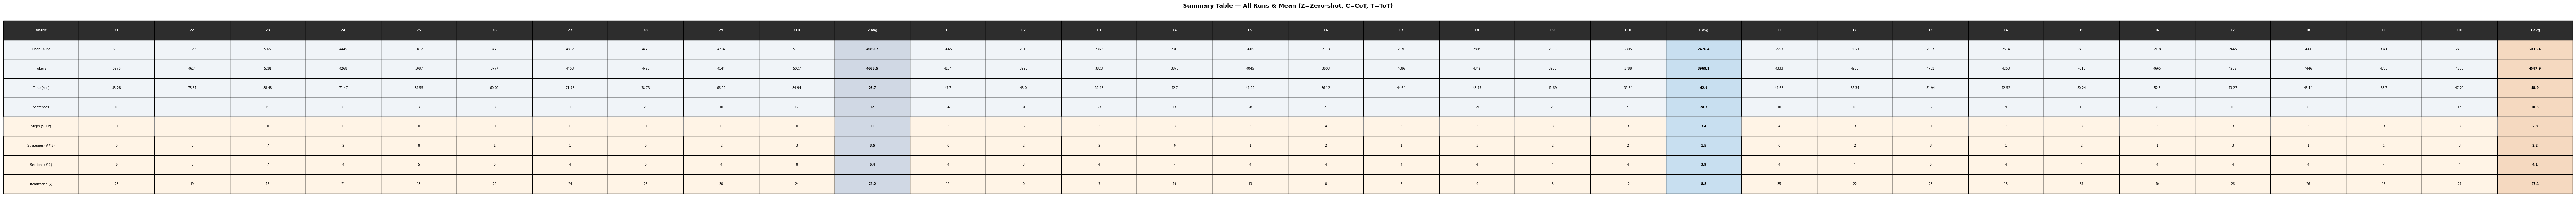

✅ 요약 테이블 저장 완료


In [ ]:
def avg(lst): return round(statistics.mean(lst), 1)

n = MAX_RUNS
metrics_config = [
    ('Char Count',      zero_shot_data,  cot_data,  tot_data,  '글자수'),
    ('Tokens',          zero_shot_data,  cot_data,  tot_data,  'total_tokens'),
    ('Time (sec)',       zero_shot_data,  cot_data,  tot_data,  'elapsed_sec'),
    ('Sentences',        zero_shot_data,  cot_data,  tot_data,  '문장수'),
    ('Steps (STEP)',     zero_shot_data2, cot_data2, tot_data2, '단계구분수'),
    ('Strategies (###)', zero_shot_data2, cot_data2, tot_data2, '전략수'),
    ('Sections (##)',    zero_shot_data2, cot_data2, tot_data2, '섹션수'),
    ('Itemization (-)',  zero_shot_data2, cot_data2, tot_data2, '항목화수'),
]

col_labels = (
    ['Metric'] +
    [f'Z{i+1}' for i in range(n)] + ['Z avg'] +
    [f'C{i+1}' for i in range(n)] + ['C avg'] +
    [f'T{i+1}' for i in range(n)] + ['T avg']
)

cell_data = []
for label, zd, cd, td, key in metrics_config:
    z_vals = zd[key]; c_vals = cd[key]; t_vals = td[key]
    row = ([label] +
           z_vals + [avg(z_vals)] +
           c_vals + [avg(c_vals)] +
           t_vals + [avg(t_vals)])
    cell_data.append(row)

fig, ax = plt.subplots(figsize=(80, 6))
ax.axis('off')
table = ax.table(cellText=cell_data, colLabels=col_labels,
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False); table.set_fontsize(7)

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2d2d2d')
    table[0, j].set_text_props(color='white', fontweight='bold')

graph1_color = '#f0f4f8'; graph2_color = '#fff4e6'
avg_color_z  = '#d0d8e4'; avg_color_c  = '#c8dff0'; avg_color_t  = '#f5d9c0'
avg_cols = [n+1, n*2+2, n*3+3]

for i in range(len(cell_data)):
    row = i + 1
    bg  = graph1_color if i < 4 else graph2_color
    for j in range(len(col_labels)):
        if   j == avg_cols[0]: table[row, j].set_facecolor(avg_color_z); table[row, j].set_text_props(fontweight='bold')
        elif j == avg_cols[1]: table[row, j].set_facecolor(avg_color_c); table[row, j].set_text_props(fontweight='bold')
        elif j == avg_cols[2]: table[row, j].set_facecolor(avg_color_t); table[row, j].set_text_props(fontweight='bold')
        else: table[row, j].set_facecolor(bg)

for j in range(len(col_labels)):
    table[5, j].set_edgecolor('#888888')

plt.suptitle('Summary Table — All Runs & Mean (Z=Zero-shot, C=CoT, T=ToT)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(DRIVE_DIR / 'summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 요약 테이블 저장 완료')